In [2]:
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pyref.fitting as fit

from utils import models_root, read_ooc

In [3]:
thicknesses = [np.float64(0.0),
  np.float64(9.988515233890404),
  np.float64(180.55434666973406),
  np.float64(11.003133679531317),
  np.float64(8.837167307453562),
  np.float64(0.0)]
roughnesses = [np.float64(0.0),
  np.float64(6.220174471477204),
  np.float64(12.301979543127507),
  np.float64(7.533760864640265),
  np.float64(5.092155307950688),
  np.float64(1.2)]

/tmp/ipykernel_14276/664275765.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  orient_range["z"] = orient_range["z"] - 75


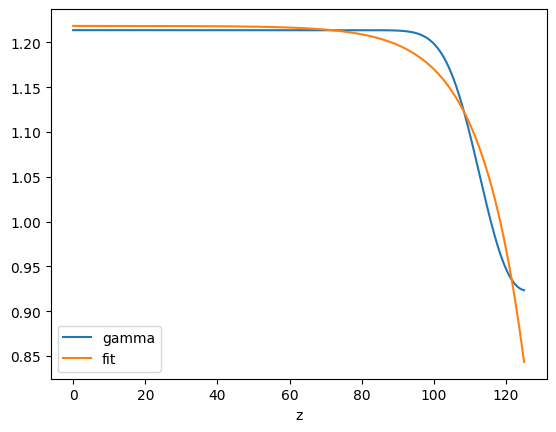


    total_thickness: 191.55748034926538
    characteristic_thickness: 12.204811944860788
    max_angle: 1.2094629719709835
    initial_angle: 0.008951710469209508
    


In [4]:
import pandas as pd
from scipy.optimize import curve_fit

df_dft = pd.read_csv("dft_slab_orientation.csv")


def orientation_profile(
    depth, total_thickness, characteristic_thickness, max_angle, initial_angle
):
    thick = total_thickness - depth
    return max_angle * (1 - np.exp(-thick / characteristic_thickness)) + initial_angle


orient_range = df_dft.query(f"z > {75} & z < {200}")
# Build new depth array for the trial fit by reseting 75 to 0
orient_range["z"] = orient_range["z"] - 75
ax = orient_range.plot(x="z", y="gamma")

popt, _ = curve_fit(orientation_profile, orient_range["z"], orient_range["gamma"])
ax.plot(orient_range["z"], orientation_profile(orient_range["z"], *popt), label="fit")
ax.legend()
plt.show()

total_thickness = thicknesses[2] + thicknesses[3]
characteristic_thickness = popt[1]
max_angle = popt[3]
initial_angle = popt[2]
print(
    f"""
    total_thickness: {total_thickness}
    characteristic_thickness: {characteristic_thickness}
    max_angle: {max_angle}
    initial_angle: {initial_angle}
    """
)

In [5]:
from utils.profile_slab import AdaptiveOrientationProfile, OrientationProfile

In [10]:
def insert_orientation_profile(structure):
    new_structure = None
    for i, component in enumerate(structure.components):
        if i == 0:
            new_structure = component
        elif i == 1:
            new_structure |= component
            # Insert the new orientation profile after the second component
            profile = AdaptiveOrientationProfile(
                ooc = oocs,
                total_thick = total_thickness,
                surface_roughness = roughnesses[2],
                density = 1.61,
                characteristic_thickness = characteristic_thickness,
                max_angle = max_angle,
                initial_angle = initial_angle,
                energy = component.sld.energy,
                energy_offset = component.sld.energy_offset,
                name = f"ZnPc_{component.sld.energy:.1f}",
            )
            profile.characteristic_thickness.setp(vary=True, bounds = (5, 25))
            profile.total_thick.setp(vary=True, bounds = (150, 210))
            profile.surface_roughness.setp(vary=True, bounds = (0, 20))
            profile.max_angle.setp(vary=True, bounds = (np.pi/4, np.pi/2))
            profile.initial_angle.setp(vary=True, bounds = (0, np.pi/4))
            profile.density.setp(vary=True, bounds = (1.4, 1.8))
            new_structure |= profile
        elif i in [2, 3]:
            # Do not add the third interface; it's replaced by the orientation profile
            continue
        else:
            new_structure |= component
    return new_structure

with open(models_root / "xrr/dft/dft_en_offset_new2.pkl", "rb") as f:
    dft_constrained = pickle.load(f)


oocs = read_ooc("dft.csv", material="znpc")

target_energies = [250, 275, 283.7, 289.0]
target_objectives = []
for o in dft_constrained.objectives:
    if o.model.energy in target_energies:
        o.model.structure = insert_orientation_profile(o.model.structure)
        target_objectives.append(o)


In [11]:
def constrain_to_probe(structure, probe_structure):
    comp = structure.components
    probe_comp = probe_structure.components

    # thicknesses
    comp[1].thick.setp(constraint=probe_comp[1].thick)
    comp[2].total_thick.setp(constraint=probe_comp[2].total_thick)
    comp[3].thick.setp(constraint=probe_comp[3].thick)

    # roughness
    comp[1].rough.setp(constraint=probe_comp[1].rough)
    comp[2].surface_roughness.setp(constraint=probe_comp[2].surface_roughness)
    comp[3].rough.setp(constraint=probe_comp[3].rough)

    # density
    comp[1].sld.density.setp(constraint=probe_comp[1].sld.density)
    comp[2].sld.density.setp(constraint=probe_comp[2].sld.density)
    comp[3].sld.density.setp(constraint=probe_comp[3].sld.density)

    # rotation
    comp[1].sld.rotation.setp(constraint=probe_comp[1].sld.rotation)
    comp[2].max_angle.setp(constraint=probe_comp[2].max_angle)
    comp[2].initial_angle.setp(constraint=probe_comp[2].initial_angle)
    comp[2].characteristic_thickness.setp(constraint=probe_comp[2].characteristic_thickness)

    return structure


for o in target_objectives:
    if o.model.energy != 283.7:
        constrain_to_probe(o.model.structure, target_objectives[2].model.structure)
    else:
        o.model.energy_offset.setp(vary=False)

In [12]:
obj = fit.GlobalObjective(target_objectives)

# Save this as a pickle for later use
with open(models_root / "xrr/profile/initialized_constrained.pkl", "wb") as f:
    pickle.dump(obj, f)

In [ ]:
fitter = fit.CurveFitter(obj)
fitter.fit(options={"workers":-1, "maxiter":50})

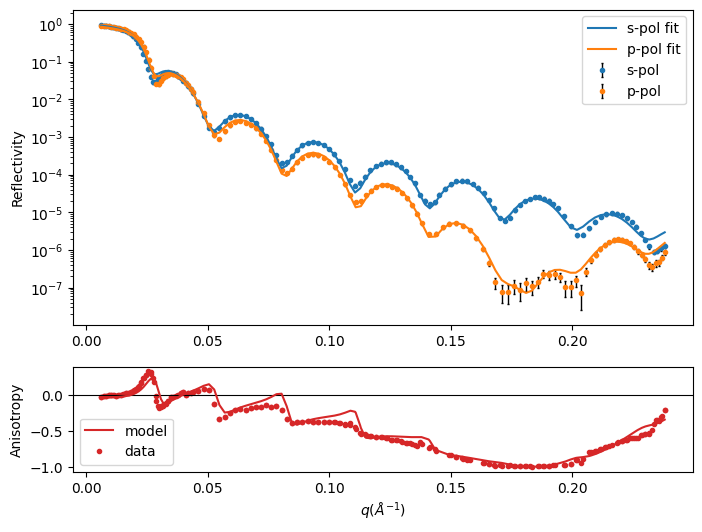

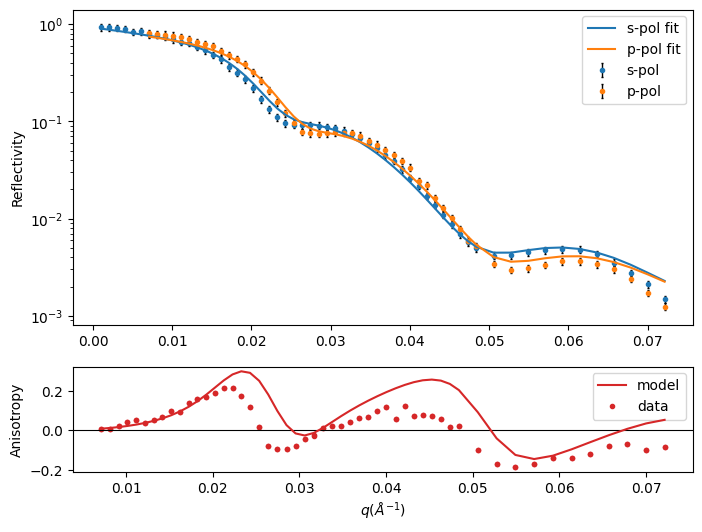

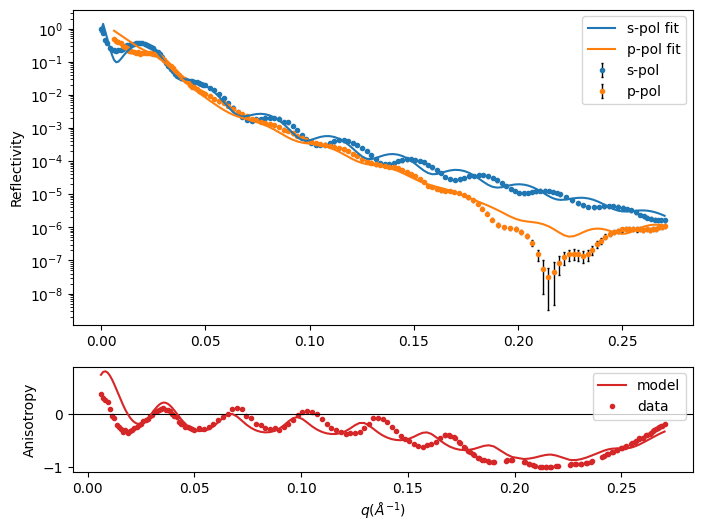

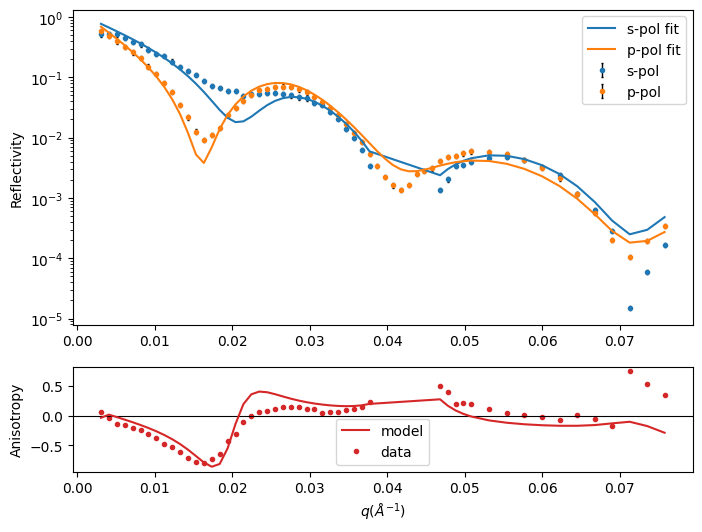

In [17]:
for o in target_objectives:
    o.plot()